In [1]:
import pyomo.environ as pyo
import mpisppy.utils.sputils as sputils
from mpisppy.opt.ef import ExtensiveForm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Configuração para que os gráficos apareçam inline no Jupyter
%matplotlib inline

[    0.00] Initializing mpi-sppy


In [2]:
from utils import carregar_pld_12m, gerar_perfis_realistas, carregar_geracao_data
from utils import load_and_process_scenario_data, plot_scenario_results

In [3]:
# --- Horizonte de Tempo ---
N = 96
TIME_HORIZON = np.arange(N)
INTERVALO_HORAS = 0.25

# --- Capacidades e Limites de Potência (W) ---
LOAD_MAX_W = 50e6               # Carga máxima
GEN_MAX_W = 150e6               # Geração Solar/Eólica máxima
MAX_ELECTROLYZER_POWER_W = 52.5e6 
MAX_THERMAL_ELEC_POWER_W = 11e6
MAX_GRID_TRADE_MW = 150         # Limite de interconexão com a rede
MAX_GRID_RAMP_MW_PER_INTERVAL = 5 # Limite de variação da rede por 15 min

# --- Armazenamento (BESS e Tanques) ---
ELEC_STORAGE_SIZE_WH = 20e6     # Capacidade BESS: 20 MWh
ELEC_STORAGE_RATE = 0.25        # Taxa de carga/descarga
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95

H2_STORAGE_SIZE_KG = 22.8e3     # Capacidade Tanque H2
H2_STORAGE_RATE = 0.3
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1

# --- Ponderações Técnicas (Eficiências e Conversões) ---
TX_ELEC_TO_H2_KWH_KG = 55.62    # Consumo específico eletrolisador
EFF_H2_TO_ELEC = 0.348          # Eficiência Turbina SGT-400
EFF_STORAGE = 0.90              # Eficiência (BESS/H2)
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400

# --- Ponderações Financeiras ---
SLACK_PENALTY = 1e9             # Penalidade por descumprimento de carga


In [4]:
MAX_ELECTROLYZER_POWER_W = 52.5e6
MIN_ELECTROLYZER_POWER_W = 0.1 * MAX_ELECTROLYZER_POWER_W
MAX_THERMAL_ELEC_POWER_W = 11e6
MIN_UPTIME_INTERVALS = 4
MAX_GRID_TRADE_MW = 50
MIN_DOWNTIME_INTERVALS = 2
SLACK_PENALTY = 1e9
H2_PRECO_COMPRA_EXTERNA = 50.0
CUSTO_STARTUP_TERMICA = 50.0
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 1500 * INTERVALO_HORAS
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95
# max_charge_power_w e max_discharge_power_w são calculados com base nos novos ELEC_STORAGE_SIZE_WH e ELEC_STORAGE_RATE
max_charge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
max_discharge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
h2_min_soc_kg = H2_STORAGE_SIZE_KG * 0.00
h2_max_soc_kg = H2_STORAGE_SIZE_KG * 1.00
max_h2_charge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
max_h2_discharge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
ammonia_min_soc_kg = AMMONIA_STORAGE_SIZE_KG * 0.0
ammonia_max_soc_kg = AMMONIA_STORAGE_SIZE_KG * 1.0

#Definir limites e quantidade para o processo de transformação H2V -> Amonia

max_ammonia_charge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS
max_ammonia_discharge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS

In [5]:
def build_model(scenario_profiles):
    model = pyo.ConcreteModel()
    model.time = pyo.Set(initialize=TIME_HORIZON)
    
    # --- Parâmetros do Modelo ---
    model.p_solar = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['solar_gen_w'])})
    model.p_wind = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['wind_gen_w'])})
    model.p_load = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['load_w'])})
    model.price = pyo.Param(model.time, initialize={t: p/1e6 for t, p in enumerate(scenario_profiles['spot_prices_mwh'])})
    model.h2_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['h2_price_venda'])})
    model.ammonia_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['ammonia_price_venda'])})

    # --- Variáveis de Decisão (Primeiro Estágio) ---
    # Representam os níveis de estoque (SOC) no instante t=0. 
    # O solver deve encontrar um valor único para estas variáveis que seja robusto 
    # para todos os cenários de PLD simultaneamente.
    model.X = pyo.Var(["ELEC_INITIAL_SOC", "H2_INITIAL_SOC", "AMMONIA_INITIAL_SOC"], within=pyo.NonNegativeReals)
    
    # --- Variáveis de Operação (Segundo Estágio) ---
    model.GRID_BUY_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.GRID_SELL_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.BESS_SOC = pyo.Var(model.time, bounds=(elec_min_soc_wh, elec_max_soc_wh))
    model.H2_STORAGE_SOC = pyo.Var(model.time, bounds=(0, H2_STORAGE_SIZE_KG))
    model.AMMONIA_STORAGE_SOC = pyo.Var(model.time, bounds=(0, AMMONIA_STORAGE_SIZE_KG))
    model.H2_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.AMMONIA_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.ELECTRICITY_SLACK_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    
    # Variáveis auxiliares de fluxo
    model.BESS_CHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_DISCHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.ELECTROLYZER_ELEC_CONSUMPTION = pyo.Var(model.time, bounds=(0, MAX_ELECTROLYZER_POWER_W))
    model.AMMONIA_PRODUCED_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.H2_PRODUCED = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.H2_TO_AMMONIA_PLANT_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.THERMAL_ELEC_GENERATION = pyo.Var(model.time, bounds=(0, MAX_THERMAL_ELEC_POWER_W))
    model.H2_TO_THERMAL_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # --- FUNÇÃO OBJETIVO: MAXIMIZAÇÃO DE LUCRO ---
    def objective_rule(m):
        receita = sum(m.h2_price_venda[t] * m.H2_TO_MARKET_MASS[t] for t in m.time) + \
                  sum(m.ammonia_price_venda[t] * m.AMMONIA_TO_MARKET_MASS[t] for t in m.time) + \
                  sum(m.price[t] * m.GRID_SELL_POWER[t] * INTERVALO_HORAS for t in m.time)
        custo = sum(m.price[t] * m.GRID_BUY_POWER[t] * INTERVALO_HORAS for t in m.time) + \
                sum(m.ELECTRICITY_SLACK_POWER[t] * SLACK_PENALTY for t in m.time)
        return receita - custo
    model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.maximize)

    # --- RESTRIÇÕES ---
    model.CONSTR = pyo.ConstraintList()
    for t in model.time:
        # 1. Balanço Elétrico
        cons_ammonia_w = model.AMMONIA_PRODUCED_MASS[t] * AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG / INTERVALO_HORAS
        model.CONSTR.add(model.p_solar[t] + model.p_wind[t] + model.BESS_DISCHARGE_POWER[t] + \
                         model.THERMAL_ELEC_GENERATION[t] + model.GRID_BUY_POWER[t] + model.ELECTRICITY_SLACK_POWER[t] == \
                         model.p_load[t] + model.BESS_CHARGE_POWER[t] + model.ELECTROLYZER_ELEC_CONSUMPTION[t] + \
                         model.GRID_SELL_POWER[t] + cons_ammonia_w)
        
        # 2. Conversão H2 (Ponderação 55.62 kWh/kg)
        model.CONSTR.add(model.H2_PRODUCED[t] == (model.ELECTROLYZER_ELEC_CONSUMPTION[t] * INTERVALO_HORAS) / (TX_ELEC_TO_H2_KWH_KG * 1000))
        
        # 3. Dinâmica de Estoque (SOC)
        soc_ant_elec = model.X["ELEC_INITIAL_SOC"] if t == 0 else model.BESS_SOC[t-1]
        model.CONSTR.add(model.BESS_SOC[t] == soc_ant_elec + (model.BESS_CHARGE_POWER[t] * 0.9 - model.BESS_DISCHARGE_POWER[t] / 0.9) * INTERVALO_HORAS)

        soc_ant_h2 = model.X["H2_INITIAL_SOC"] if t == 0 else model.H2_STORAGE_SOC[t-1]
        model.CONSTR.add(model.H2_STORAGE_SOC[t] == soc_ant_h2 + model.H2_PRODUCED[t] - \
                         model.H2_TO_MARKET_MASS[t] - model.H2_TO_THERMAL_MASS[t] - model.H2_TO_AMMONIA_PLANT_MASS[t])

        soc_ant_nh3 = model.X["AMMONIA_INITIAL_SOC"] if t == 0 else model.AMMONIA_STORAGE_SOC[t-1]
        model.CONSTR.add(model.AMMONIA_STORAGE_SOC[t] == soc_ant_nh3 + model.AMMONIA_PRODUCED_MASS[t] - model.AMMONIA_TO_MARKET_MASS[t])
        model.CONSTR.add(model.AMMONIA_PRODUCED_MASS[t] == model.H2_TO_AMMONIA_PLANT_MASS[t] / TX_H2_TO_AMMONIA_KG_PER_KG)

    # 4. Condições de Contorno Finais (Sustentabilidade SOC_f >= SOC_i)
    # Estas restrições obrigam o sistema a terminar o horizonte de 24h com um estoque 
    # igual ou superior ao inicial (model.X). Isso evita que o otimizador "esvazie" 
    # os tanques para lucrar artificialmente em um único dia, garantindo a 
    # continuidade da operação para o dia seguinte.    
    model.CONSTR.add(model.BESS_SOC[N-1] >= model.X["ELEC_INITIAL_SOC"])
    model.CONSTR.add(model.H2_STORAGE_SOC[N-1] >= model.X["H2_INITIAL_SOC"])
    model.CONSTR.add(model.AMMONIA_STORAGE_SOC[N-1] >= model.X["AMMONIA_INITIAL_SOC"])

    return model

In [6]:
nome_do_arquivo_pld = '../market-data/PLD_NE_12_meses.xlsx'
nome_do_arquivo_solar_real = '../solar-data/Geracao-Solar.xlsx'
nome_do_arquivo_eolica = '../wind-data/wind_data.xlsx'

try:
    pasta_do_script = os.path.dirname(os.path.abspath(__file__))
except NameError:
    pasta_do_script = os.getcwd()

caminho_pld_12meses = os.path.join(pasta_do_script, nome_do_arquivo_pld)
caminho_solar_data = os.path.join(pasta_do_script, nome_do_arquivo_solar_real)
caminho_wind_data = os.path.join(pasta_do_script, nome_do_arquivo_eolica)


In [7]:
# --- Carregamento e processamento dos dados de PLD ---
pld_data_for_scenarios = None
scenario_probabilities = {} # Dicionário global para as probabilidades reais

try:
    df_pld_completo = carregar_pld_12m(caminho_pld_12meses)
    print(f"Arquivo '{nome_do_arquivo_pld}' carregado. {len(df_pld_completo)} registros.")
    
    # --- CÁLCULO DAS PROBABILIDADES REAIS (DATA-DRIVEN) ---
    pld_total = df_pld_completo['pld']
    total_obs = len(pld_total)
    
    # Baseado nos quantis que você usa para os perfis (0.10 e 0.90)
    limite_baixo = pld_total.quantile(0.10)
    limite_alto = pld_total.quantile(0.90)
    
    # Contagem de ocorrências reais no histórico
    count_low = len(pld_total[pld_total <= limite_baixo])
    count_high = len(pld_total[pld_total >= limite_alto])
    count_mean = total_obs - (count_low + count_high)
    
    # Atribuição das probabilidades reais
    scenario_probabilities = {
        'optimal': count_low / total_obs,  # ~10%
        'bad': count_high / total_obs,      # ~10%
        'good': count_mean / total_obs      # ~80%
    }
    
    print(f"Probabilidades reais aplicadas:")
    print(f"  - Ótimo (Low): {scenario_probabilities['optimal']:.2%}")
    print(f"  - Médio (Mean): {scenario_probabilities['good']:.2%}")
    print(f"  - Ruim (High): {scenario_probabilities['bad']:.2%}")

    # --- GERAÇÃO DOS PERFIS HORÁRIOS ---
    df_pld_completo['hour'] = df_pld_completo['data'].dt.hour
    pld_alto_horario = df_pld_completo.groupby('hour')['pld'].quantile(0.90).reindex(range(24)).ffill().to_numpy()
    pld_medio_horario = df_pld_completo.groupby('hour')['pld'].median().reindex(range(24)).ffill().to_numpy()
    pld_baixo_horario = df_pld_completo.groupby('hour')['pld'].quantile(0.10).reindex(range(24)).ffill().to_numpy()

    def interpolar_pld_para_15min(pld_horario):
        horas_originais = np.arange(24)
        horas_alvo = np.arange(0, 24, INTERVALO_HORAS)
        return np.interp(horas_alvo, horas_originais, np.roll(pld_horario, 1))

    pld_data_for_scenarios = {
        'high': interpolar_pld_para_15min(pld_alto_horario).tolist(),
        'mean': interpolar_pld_para_15min(pld_medio_horario).tolist(),
        'low': interpolar_pld_para_15min(pld_baixo_horario).tolist()
    }

except (FileNotFoundError, ValueError) as e:
    print(f"\n*** ERRO CRÍTICO: {e} ***")
    exit()

Arquivo '../market-data/PLD_NE_12_meses.xlsx' carregado. 8760 registros.
Probabilidades reais aplicadas:
  - Ótimo (Low): 34.98%
  - Médio (Mean): 55.02%
  - Ruim (High): 10.00%


In [8]:
def scenario_creator(scenario_name, all_profiles, **kwargs):
    if scenario_name not in all_profiles:
        raise ValueError(f"Perfil para o cenário '{scenario_name}' não encontrado.")
    
    scenario_data = all_profiles[scenario_name]
    model = build_model(scenario_data)
    
    # Vincula as variáveis de primeiro estágio (SOC Inicial)
    # Vincula as variáveis de primeiro estágio ao "Nó Raiz" (Root Node).
    # Isso impõe a restrição de não-antecipatividade: a decisão do estoque inicial 
    # deve ser a mesma, independente de qual cenário de PLD venha a ocorrer.
    sputils.attach_root_node(model, 0.0, list(model.X.values()))
    
    # --- AJUSTE DE PROBABILIDADE REAL ---
    # Atribui a probabilidade calculada estatisticamente
    model._mpisppy_probability = scenario_probabilities[scenario_name]
    
    return model


In [9]:
pld_alto_horario

array([288.782, 287.2  , 286.678, 287.2  , 289.56 , 272.988, 220.412,
       117.398, 119.252, 220.738, 238.175, 243.388, 270.268, 281.736,
       292.438, 306.972, 321.246, 341.346, 454.634, 321.652, 307.85 ,
       301.016, 294.386, 291.348])

In [10]:
pld_baixo_horario

array([58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6,
       58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6, 58.6,
       58.6, 58.6])

In [11]:
pld_medio_horario

array([61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07,
       61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 61.07, 62.06,
       62.07, 61.07, 61.07, 61.07, 61.07, 61.07])

In [12]:
# --- Carregamento e processamento dos dados reais de Geração Solar e Eólica ---
solar_mean_profile_aggregated = None
wind_mean_profile_aggregated = None

try:
   # print(f"\n--- Processando dados de Geração Solar Reais (Média Agregada) do arquivo '{nome_do_arquivo_solar}' ---")
    solar_mean_profile_aggregated = carregar_geracao_data(
        caminho_solar_data, N_intervals=N, unit_conversion_factor=1e6, sheet_name=0
    )
 #   print(f"Perfil Solar de Média Agregada: {len(solar_mean_profile_aggregated)} pontos.")
 #   print("Primeiros 10 valores do perfil solar agregado (Watts):", solar_mean_profile_aggregated[:10])
   #  print("Últimos 10 valores do perfil solar agregado (Watts):", solar_mean_profile_aggregated[-10:])
   #  print("Valor máximo no perfil solar agregado (Watts):", max(solar_mean_profile_aggregated))
   #  print("Valor mínimo no perfil solar agregado (Watts):", min(solar_mean_profile_aggregated))
except (FileNotFoundError, ValueError) as e:
   #  print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO SOLAR: {e} ***")
   #  print("A execução foi interrompida. Verifique o arquivo e o caminho.")
   exit()
    

In [13]:
solar_mean_profile_aggregated

In [14]:
#plt.plot(solar_mean_profile_aggregated)

In [15]:
try:
   #  print(f"\n--- Processando dados de Geração Eólica Reais (Média Agregada) do arquivo '{nome_do_arquivo_eolica}' ---")
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, N_intervals=N, unit_conversion_factor=1e6, sheet_name=0
    )
   #  print(f"Perfil Eólico de Média Agregada: {len(wind_mean_profile_aggregated)} pontos.")
   #  print("Primeiros 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[:10])
   #  print("Últimos 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[-10:])
   #  print("Valor máximo no perfil eólico agregado (Watts):", max(wind_mean_profile_aggregated))
   #  print("Valor mínimo no perfil eólico agregado (Watts):", min(wind_mean_profile_aggregated))
except (FileNotFoundError, ValueError) as e:
   #  print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO EÓLICO: {e} ***")
   #  print("A execução foi interrompida. Verifique o arquivo e o caminho.")
    exit()

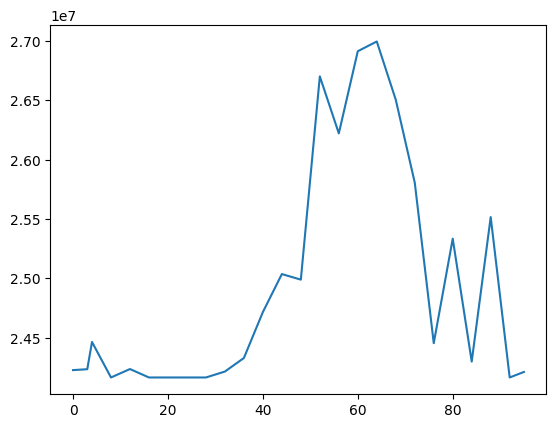

In [16]:
plt.plot(wind_mean_profile_aggregated)

In [17]:
h2_price_to_test = 60.00
ammonia_prices_to_test = [10.00]

ammonia_price = ammonia_prices_to_test[0]

# Passamos os perfis de média agregada para solar e eólica para a função
all_scenario_profiles = load_and_process_scenario_data(
    N,
    INTERVALO_HORAS,
    LOAD_MAX_W,               # Carga máxima
    GEN_MAX_W,               # Geração Solar/Eólica máxima
    pld_data=pld_data_for_scenarios,
    solar_mean_profile=solar_mean_profile_aggregated,
    wind_mean_profile=wind_mean_profile_aggregated,
    fixed_h2_price=h2_price_to_test,
    fixed_ammonia_price=ammonia_price
)

#   print("\nIniciando a resolução do Modelo Estocástico...")
all_scenario_names = ["optimal", "good", "bad"]
options = {"solver": "cplex"}

creator_with_data = lambda scenario_name, **kwargs: scenario_creator(
    scenario_name, all_profiles=all_scenario_profiles, **kwargs
)

--- Construindo perfis: Preço H₂ (Venda) = R$ 60.00/kg | Preço Amônia (Venda) = R$ 10.00/kg ---


In [18]:
all_scenario_names

['optimal', 'good', 'bad']

In [19]:
all_scenario_profiles.keys()

dict_keys(['optimal', 'good', 'bad'])

In [20]:
all_scenario_profiles['optimal'].keys()

dict_keys(['wind_gen_w', 'solar_gen_w', 'spot_prices_mwh', 'load_w', 'h2_price_venda', 'ammonia_price_venda'])

In [21]:
creator_with_data('optimal')

TypeError: 'NoneType' object is not iterable

In [ ]:
# --- 1. Configuração e Resolução do Modelo Estocástico ---
all_scenario_names = ["optimal", "good", "bad"]
options = {"solver": "cplex"}

# Função criadora vinculada aos dados
creator_with_data = lambda scenario_name, **kwargs: scenario_creator(
    scenario_name, all_profiles=all_scenario_profiles, **kwargs
)

# Construção da Forma Extensiva (Estocástico)
ef_builder = ExtensiveForm(options, all_scenario_names, creator_with_data)
solver = pyo.SolverFactory(options["solver"])

# Execução do Solver
results = solver.solve(ef_builder.ef, tee=True)

# --- 2. Processamento dos Resultados ---
if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
    ef_model = ef_builder.ef
    expected_profit = pyo.value(ef_model.EF_Obj)
    print(f"\nValor Objetivo Ótimo (Lucro Esperado Total): R$ {expected_profit:,.2f}")

    # Extraímos o SOC Inicial (Decisão de Primeiro Estágio - igual para todos os cenários)
    first_block = getattr(ef_model, all_scenario_names[0])
    initial_socs = {
        'elec': pyo.value(first_block.X['ELEC_INITIAL_SOC']),
        'h2': pyo.value(first_block.X['H2_INITIAL_SOC']),
        'ammonia': pyo.value(first_block.X['ammonia_INITIAL_SOC']) if 'ammonia_INITIAL_SOC' in first_block.X else pyo.value(first_block.X['AMMONIA_INITIAL_SOC'])
    }

    # --- 3. EXIBIÇÃO APENAS DO MELHOR CENÁRIO ('optimal') ---
    # Mantemos a estocasticidade na resolução, mas focamos a análise visual no melhor caso
    cenario_para_exibir = "optimal"
    print(f"\n--- Exibindo Resultados Detalhados: Cenário {cenario_para_exibir.upper()} ---")
    
    s_block = getattr(ef_model, cenario_para_exibir)
    
    plot_scenario_results(
        TIME_HORIZON,
        s_block, 
        cenario_para_exibir, 
        initial_socs, 
        fixed_h2_price=h2_price_to_test,
        fixed_ammonia_price=ammonia_price,
        AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG=AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG,
        INTERVALO_HORAS=INTERVALO_HORAS,
        N=N,
        h2_max_soc_kg=h2_max_soc_kg,
        h2_min_soc_kg=h2_min_soc_kg,
        ammonia_max_soc_kg=ammonia_max_soc_kg,
        ammonia_min_soc_kg=ammonia_min_soc_kg,
        TX_H2_TO_AMMONIA_KG_PER_KG=TX_H2_TO_AMMONIA_KG_PER_KG
    )
else:
    print(f"\nO solver não encontrou uma solução ótima. Condição: {results.solver.termination_condition}")

In [ ]:
getattr(ef_model, 'optimal')